In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)


In [2]:
df = pd.read_csv("../data/raw/vahan_vehicle_registrations.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 584267
Columns: 10


In [3]:
df = df[
    [
        "date",
        "state_name",
        "vehicle_type",
        "registrations"
    ]
]

df.head()

,date,state_name,vehicle_type,registrations
0,2020-04-01T00:00:00,Andaman And Nicobar Islands,Heavy Goods Vehicle,8.0
1,2020-04-01T00:00:00,Andaman And Nicobar Islands,Light Goods Vehicle,19.0
2,2020-04-01T00:00:00,Andaman And Nicobar Islands,Light Motor Vehicle,12.0
3,2020-04-01T00:00:00,Andaman And Nicobar Islands,Light Passenger Vehicle,4.0
4,2020-04-01T00:00:00,Andaman And Nicobar Islands,Other Than Mentioned Above,1.0


In [4]:
df.columns = [
    "date",
    "state",
    "vehicle_type",
    "registrations"
]

df.head()

,date,state,vehicle_type,registrations
0,2020-04-01T00:00:00,Andaman And Nicobar Islands,Heavy Goods Vehicle,8.0
1,2020-04-01T00:00:00,Andaman And Nicobar Islands,Light Goods Vehicle,19.0
2,2020-04-01T00:00:00,Andaman And Nicobar Islands,Light Motor Vehicle,12.0
3,2020-04-01T00:00:00,Andaman And Nicobar Islands,Light Passenger Vehicle,4.0
4,2020-04-01T00:00:00,Andaman And Nicobar Islands,Other Than Mentioned Above,1.0


In [5]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(df["date"].min())
print(df["date"].max())

2019-01-01 00:00:00
2024-05-01 00:00:00


In [6]:
df.isnull().sum()

date             0
state            0
vehicle_type     0
registrations    0
dtype: int64

In [7]:
df = df.dropna(
    subset=["date", "state", "vehicle_type", "registrations"]
)

In [8]:
print("Rows after removing missing values:", len(df))

Rows after removing missing values: 584267


In [9]:
df["state"] = df["state"].str.strip()
df["vehicle_type"] = df["vehicle_type"].str.strip()

In [10]:
df["registrations"] = pd.to_numeric(
    df["registrations"],
    errors="coerce"
)

In [11]:
print(df["registrations"].dtype)

float64


In [12]:
df = df[df["registrations"] >= 0]

In [13]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 231872


In [14]:
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()

In [15]:
monthly_df = (
    df.groupby(
        ["month", "state", "vehicle_type"],
        as_index=False
    )["registrations"]
    .sum()
)

In [16]:
monthly_df.head(20)

,month,state,vehicle_type,registrations
0,2019-01-01,Andaman And Nicobar Islands,Heavy Goods Vehicle,9.0
1,2019-01-01,Andaman And Nicobar Islands,Heavy Passenger Vehicle,1.0
2,2019-01-01,Andaman And Nicobar Islands,Light Goods Vehicle,21.0
3,2019-01-01,Andaman And Nicobar Islands,Light Motor Vehicle,161.0
4,2019-01-01,Andaman And Nicobar Islands,Light Passenger Vehicle,27.0
5,2019-01-01,Andaman And Nicobar Islands,Medium Goods Vehicle,1.0
6,2019-01-01,Andaman And Nicobar Islands,Medium Passenger Vehicle,1.0
7,2019-01-01,Andaman And Nicobar Islands,Three Wheeler(T),8.0
8,2019-01-01,Andaman And Nicobar Islands,Two Wheeler(Nt),624.0
9,2019-01-01,Andaman And Nicobar Islands,Two Wheeler(T),17.0


In [17]:
print("Rows:", len(monthly_df))
print("Columns:", len(monthly_df.columns))

monthly_df.info()

Rows: 27684
Columns: 4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27684 entries, 0 to 27683
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   month          27684 non-null  datetime64[ns]
 1   state          27684 non-null  object        
 2   vehicle_type   27684 non-null  object        
 3   registrations  27684 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 865.3+ KB


In [18]:
monthly_df["vehicle_type"].value_counts()

vehicle_type
Light Motor Vehicle                2208
Two Wheeler(Nt)                    2203
Light Goods Vehicle                2195
Light Passenger Vehicle            2182
Heavy Goods Vehicle                2151
Medium Goods Vehicle               2086
Three Wheeler(T)                   2057
Other Than Mentioned Above         1905
Medium Passenger Vehicle           1831
Heavy Passenger Vehicle            1727
Medium Motor Vehicle               1662
Heavy Motor Vehicle                1560
Four Wheeler (Invalid Carriage)    1114
Two Wheeler(T)                     1077
Two Wheeler (Invalid Carriage)     1015
Three Wheeler(Nt)                   711
Name: count, dtype: int64

In [19]:
vehicle_summary = (
    monthly_df.groupby("vehicle_type")["registrations"]
    .sum()
    .sort_values(ascending=False)
)

vehicle_summary

vehicle_type
Two Wheeler(Nt)                    564249065.0
Light Motor Vehicle                133354415.0
Light Goods Vehicle                 19803961.0
Three Wheeler(T)                    19708335.0
Heavy Goods Vehicle                  6500802.0
Light Passenger Vehicle              5184433.0
Other Than Mentioned Above           1763596.0
Medium Goods Vehicle                 1189641.0
Heavy Passenger Vehicle               622030.0
Medium Motor Vehicle                  580276.0
Medium Passenger Vehicle              459019.0
Two Wheeler (Invalid Carriage)        457202.0
Three Wheeler(Nt)                     442967.0
Two Wheeler(T)                        380061.0
Heavy Motor Vehicle                   176943.0
Four Wheeler (Invalid Carriage)        75379.0
Name: registrations, dtype: float64

In [20]:
print("Number of states/UTs:",
      monthly_df["state"].nunique())

Number of states/UTs: 34


In [21]:
monthly_df["state"].value_counts()

state
Kerala                                          1036
Karnataka                                       1031
Rajasthan                                       1019
Andhra Pradesh                                  1003
Gujarat                                         1003
Tamil Nadu                                       986
Arunachal Pradesh                                979
Uttar Pradesh                                    974
Maharashtra                                      951
Madhya Pradesh                                   947
Punjab                                           918
West Bengal                                      911
Odisha                                           898
Himachal Pradesh                                 896
Uttarakhand                                      886
Haryana                                          885
Bihar                                            874
Chhattisgarh                                     859
Goa                                     

In [22]:
print("First month:",
      monthly_df["month"].min())

print("Last month:",
      monthly_df["month"].max())

print("Number of months:",
      monthly_df["month"].nunique())

First month: 2019-01-01 00:00:00
Last month: 2024-05-01 00:00:00
Number of months: 65


In [23]:
print(
    "Zero-registration rows:",
    (monthly_df["registrations"] == 0).sum()
)

Zero-registration rows: 0


In [24]:
monthly_df.to_csv(
    "../data/processed/monthly_vehicle_demand.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [25]:
vehicle_summary

vehicle_type
Two Wheeler(Nt)                    564249065.0
Light Motor Vehicle                133354415.0
Light Goods Vehicle                 19803961.0
Three Wheeler(T)                    19708335.0
Heavy Goods Vehicle                  6500802.0
Light Passenger Vehicle              5184433.0
Other Than Mentioned Above           1763596.0
Medium Goods Vehicle                 1189641.0
Heavy Passenger Vehicle               622030.0
Medium Motor Vehicle                  580276.0
Medium Passenger Vehicle              459019.0
Two Wheeler (Invalid Carriage)        457202.0
Three Wheeler(Nt)                     442967.0
Two Wheeler(T)                        380061.0
Heavy Motor Vehicle                   176943.0
Four Wheeler (Invalid Carriage)        75379.0
Name: registrations, dtype: float64

In [26]:
monthly_df.head(20)

,month,state,vehicle_type,registrations
0,2019-01-01,Andaman And Nicobar Islands,Heavy Goods Vehicle,9.0
1,2019-01-01,Andaman And Nicobar Islands,Heavy Passenger Vehicle,1.0
2,2019-01-01,Andaman And Nicobar Islands,Light Goods Vehicle,21.0
3,2019-01-01,Andaman And Nicobar Islands,Light Motor Vehicle,161.0
4,2019-01-01,Andaman And Nicobar Islands,Light Passenger Vehicle,27.0
5,2019-01-01,Andaman And Nicobar Islands,Medium Goods Vehicle,1.0
6,2019-01-01,Andaman And Nicobar Islands,Medium Passenger Vehicle,1.0
7,2019-01-01,Andaman And Nicobar Islands,Three Wheeler(T),8.0
8,2019-01-01,Andaman And Nicobar Islands,Two Wheeler(Nt),624.0
9,2019-01-01,Andaman And Nicobar Islands,Two Wheeler(T),17.0


In [27]:
monthly_df["state"].nunique()
monthly_df["month"].min()
monthly_df["month"].max()

Timestamp('2024-05-01 00:00:00')

In [28]:
vehicle_group_mapping = {

    # Two Wheelers
    "Two Wheeler(Nt)": "Two Wheeler",
    "Two Wheeler(T)": "Two Wheeler",

    # Three Wheelers
    "Three Wheeler(Nt)": "Three Wheeler",
    "Three Wheeler(T)": "Three Wheeler",

    # Passenger / Personal Vehicles
    "Light Motor Vehicle": "Passenger Vehicle",
    "Light Passenger Vehicle": "Passenger Vehicle",

    # Goods Vehicles
    "Light Goods Vehicle": "Goods Vehicle",
    "Medium Goods Vehicle": "Goods Vehicle",
    "Heavy Goods Vehicle": "Goods Vehicle",

    # Passenger Transport
    "Medium Passenger Vehicle": "Passenger Transport",
    "Heavy Passenger Vehicle": "Passenger Transport",

    # Other Motor Vehicles
    "Medium Motor Vehicle": "Other Motor Vehicle",
    "Heavy Motor Vehicle": "Other Motor Vehicle"
}

In [29]:
monthly_df["vehicle_group"] = (
    monthly_df["vehicle_type"]
    .map(vehicle_group_mapping)
)

In [30]:
monthly_df[
    ["vehicle_type", "vehicle_group"]
].drop_duplicates().sort_values("vehicle_group")

,vehicle_type,vehicle_group
0,Heavy Goods Vehicle,Goods Vehicle
2,Light Goods Vehicle,Goods Vehicle
5,Medium Goods Vehicle,Goods Vehicle
12,Heavy Motor Vehicle,Other Motor Vehicle
18,Medium Motor Vehicle,Other Motor Vehicle
1,Heavy Passenger Vehicle,Passenger Transport
6,Medium Passenger Vehicle,Passenger Transport
3,Light Motor Vehicle,Passenger Vehicle
4,Light Passenger Vehicle,Passenger Vehicle
7,Three Wheeler(T),Three Wheeler


In [31]:
monthly_df[
    monthly_df["vehicle_group"].isna()
]["vehicle_type"].unique()

array(['Four Wheeler (Invalid Carriage)', 'Other Than Mentioned Above',
       'Two Wheeler (Invalid Carriage)'], dtype=object)

In [32]:
monthly_df = monthly_df[
    monthly_df["vehicle_group"].notna()
].copy()

In [33]:
monthly_df["vehicle_group"].value_counts()

vehicle_group
Goods Vehicle          6432
Passenger Vehicle      4390
Passenger Transport    3558
Two Wheeler            3280
Other Motor Vehicle    3222
Three Wheeler          2768
Name: count, dtype: int64

In [34]:
group_summary = (
    monthly_df
    .groupby("vehicle_group")["registrations"]
    .sum()
    .sort_values(ascending=False)
)

group_summary

vehicle_group
Two Wheeler            564629126.0
Passenger Vehicle      138538848.0
Goods Vehicle           27494404.0
Three Wheeler           20151302.0
Passenger Transport      1081049.0
Other Motor Vehicle       757219.0
Name: registrations, dtype: float64

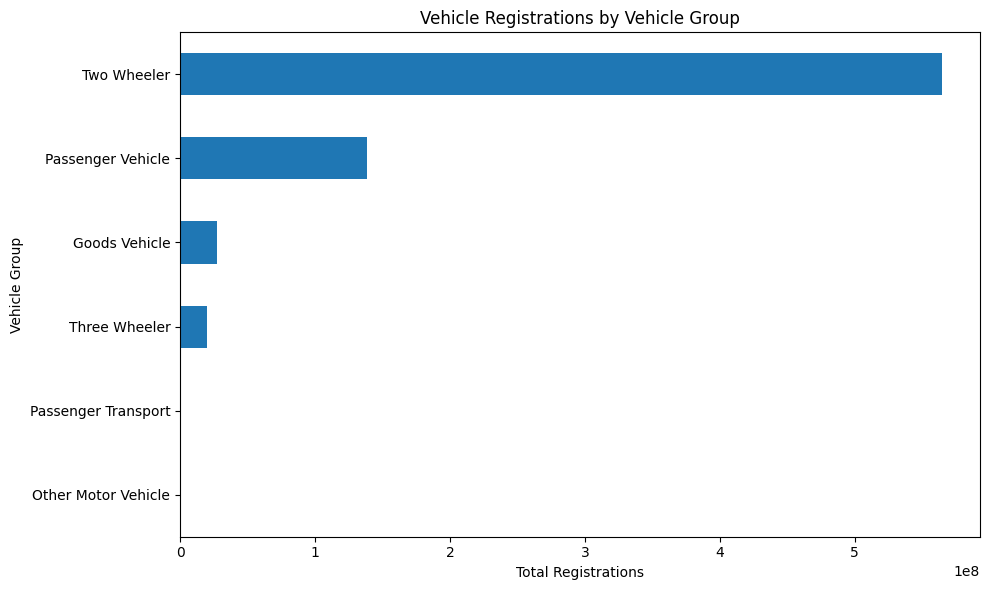

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

group_summary.sort_values().plot(kind="barh")

plt.title("Vehicle Registrations by Vehicle Group")
plt.xlabel("Total Registrations")
plt.ylabel("Vehicle Group")

plt.tight_layout()
plt.show()

In [38]:
monthly_df["vehicle_group"].value_counts()

vehicle_group
Goods Vehicle          6432
Passenger Vehicle      4390
Passenger Transport    3558
Two Wheeler            3280
Other Motor Vehicle    3222
Three Wheeler          2768
Name: count, dtype: int64

In [39]:
group_summary

vehicle_group
Two Wheeler            564629126.0
Passenger Vehicle      138538848.0
Goods Vehicle           27494404.0
Three Wheeler           20151302.0
Passenger Transport      1081049.0
Other Motor Vehicle       757219.0
Name: registrations, dtype: float64

In [40]:
monthly_df[
    monthly_df["vehicle_group"].isna()
]["vehicle_type"].unique()

array([], dtype=object)

In [41]:
monthly_df.shape

(23650, 5)

In [42]:
print(monthly_df.shape)

(23650, 5)


In [43]:
monthly_df.to_csv(
    "../data/processed/monthly_vehicle_demand.csv",
    index=False
)

print("Final cleaned dataset saved!")

Final cleaned dataset saved!
